In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df = pd.read_excel(
    '/content/drive/MyDrive/customer_churn_prediction/Telco_customer_churn.xlsx'
)

In [ ]:
df.shape

(7043, 33)

In [ ]:
df.head()

,CustomerID,Count,Country,State,City,Zip Code,Lat Long,Latitude,Longitude,Gender,...,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label,Churn Value,Churn Score,CLTV,Churn Reason
0,3668-QPYBK,1,United States,California,Los Angeles,90003,"33.964131, -118.272783",33.964131,-118.272783,Male,...,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1,86,3239,Competitor made better offer
1,9237-HQITU,1,United States,California,Los Angeles,90005,"34.059281, -118.30742",34.059281,-118.307420,Female,...,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1,67,2701,Moved
2,9305-CDSKC,1,United States,California,Los Angeles,90006,"34.048013, -118.293953",34.048013,-118.293953,Female,...,Month-to-month,Yes,Electronic check,99.65,820.5,Yes,1,86,5372,Moved
3,7892-POOKP,1,United States,California,Los Angeles,90010,"34.062125, -118.315709",34.062125,-118.315709,Female,...,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes,1,84,5003,Moved
4,0280-XJGEX,1,United States,California,Los Angeles,90015,"34.039224, -118.266293",34.039224,-118.266293,Male,...,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.3,Yes,1,89,5340,Competitor had better devices


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 33 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CustomerID         7043 non-null   object 
 1   Count              7043 non-null   int64  
 2   Country            7043 non-null   object 
 3   State              7043 non-null   object 
 4   City               7043 non-null   object 
 5   Zip Code           7043 non-null   int64  
 6   Lat Long           7043 non-null   object 
 7   Latitude           7043 non-null   float64
 8   Longitude          7043 non-null   float64
 9   Gender             7043 non-null   object 
 10  Senior Citizen     7043 non-null   object 
 11  Partner            7043 non-null   object 
 12  Dependents         7043 non-null   object 
 13  Tenure Months      7043 non-null   int64  
 14  Phone Service      7043 non-null   object 
 15  Multiple Lines     7043 non-null   object 
 16  Internet Service   7043 

In [ ]:
df.isnull().sum()

,0
CustomerID,0
Count,0
Country,0
State,0
City,0
Zip Code,0
Lat Long,0
Latitude,0
Longitude,0
Gender,0


In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df['Churn Label'].value_counts()

,count
Churn Label,
No,5174
Yes,1869


In [ ]:
df['Churn Label'].value_counts(normalize=True) * 100

,proportion
Churn Label,
No,73.463013
Yes,26.536987


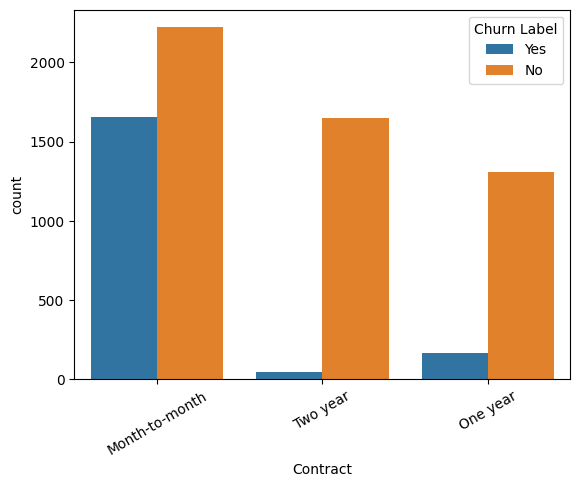

In [ ]:
sns.countplot(x='Contract', hue='Churn Label', data=df)
plt.xticks(rotation=30)
plt.show()

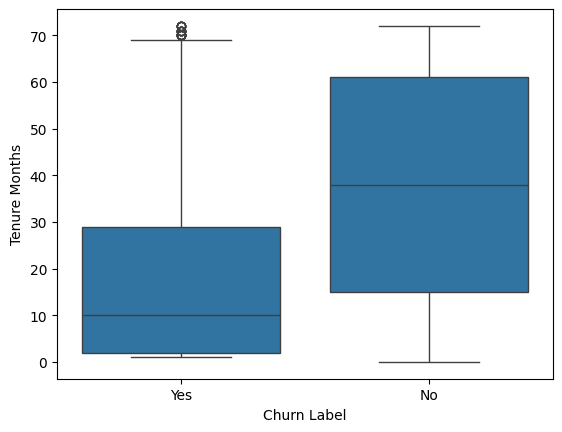

In [ ]:
sns.boxplot(x='Churn Label', y='Tenure Months', data=df)
plt.show()

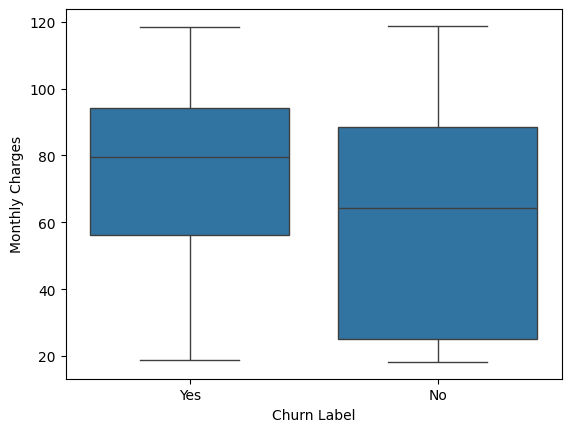

In [ ]:
sns.boxplot(x='Churn Label', y='Monthly Charges', data=df)
plt.show()

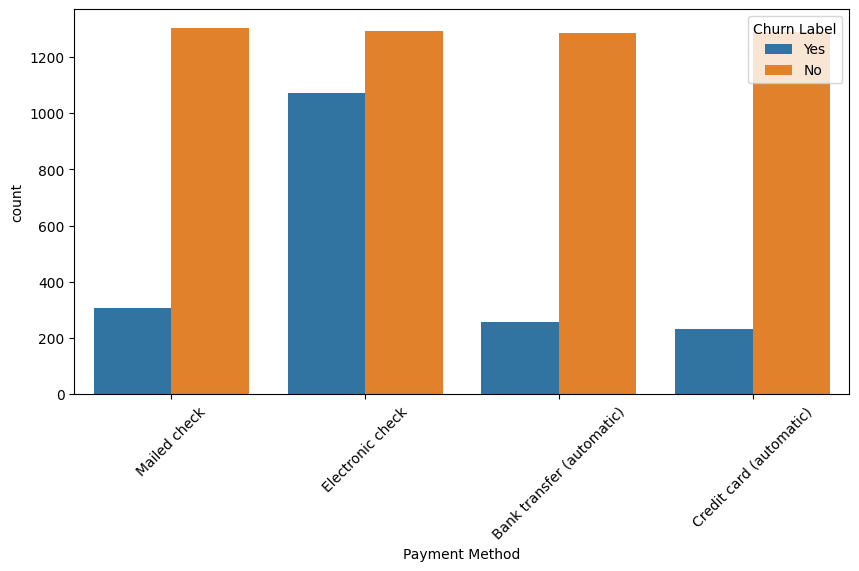

In [ ]:
plt.figure(figsize=(10,5))
sns.countplot(x='Payment Method', hue='Churn Label', data=df)
plt.xticks(rotation=45)
plt.show()

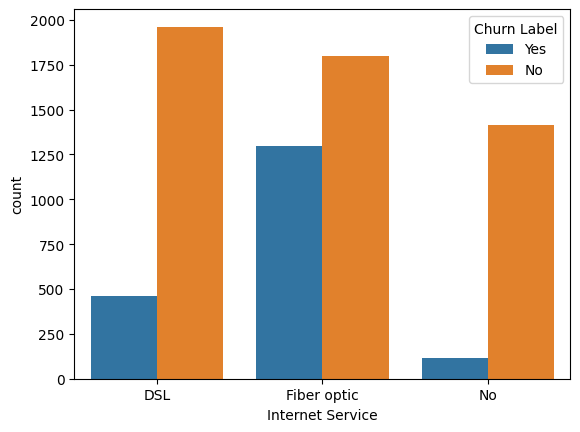

In [ ]:
sns.countplot(x='Internet Service', hue='Churn Label', data=df)
plt.show()

In [ ]:
df['Total Charges'] = pd.to_numeric(
    df['Total Charges'],
    errors='coerce'
)

df.dropna(subset=['Total Charges'], inplace=True)

In [ ]:
drop_cols = [
    'CustomerID',
    'Count',
    'Country',
    'State',
    'City',
    'Zip Code',
    'Lat Long',
    'Latitude',
    'Longitude',
    'Churn Reason',
    'Churn Score',
    'CLTV',
    'Churn Label'
]

df.drop(columns=drop_cols, inplace=True)

In [ ]:
df.shape

(7032, 20)

In [ ]:
X = df.drop('Churn Value', axis=1)
y = df['Churn Value']

In [ ]:
X.shape
y.shape

(7032,)

In [ ]:
X.dtypes

,0
Gender,object
Senior Citizen,object
Partner,object
Dependents,object
Tenure Months,int64
Phone Service,object
Multiple Lines,object
Internet Service,object
Online Security,object
Online Backup,object


In [ ]:
X = pd.get_dummies(X, drop_first=True)

In [ ]:
X.shape
X.head()

,Tenure Months,Monthly Charges,Total Charges,Gender_Male,Senior Citizen_Yes,Partner_Yes,Dependents_Yes,Phone Service_Yes,Multiple Lines_No phone service,Multiple Lines_Yes,...,Streaming TV_No internet service,Streaming TV_Yes,Streaming Movies_No internet service,Streaming Movies_Yes,Contract_One year,Contract_Two year,Paperless Billing_Yes,Payment Method_Credit card (automatic),Payment Method_Electronic check,Payment Method_Mailed check
0,2,53.85,108.15,True,False,False,False,True,False,False,...,False,False,False,False,False,False,True,False,False,True
1,2,70.70,151.65,False,False,False,True,True,False,False,...,False,False,False,False,False,False,True,False,True,False
2,8,99.65,820.50,False,False,False,True,True,False,True,...,False,True,False,True,False,False,True,False,True,False
3,28,104.80,3046.05,False,False,True,True,True,False,True,...,False,True,False,True,False,False,True,False,True,False
4,49,103.70,5036.30,True,False,False,True,True,False,True,...,False,True,False,True,False,False,True,False,False,False


In [ ]:
from sklearn.model_selection import train_test_split

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [ ]:
X_train.shape
X_test.shape

(1407, 30)

In [ ]:
from imblearn.over_sampling import SMOTE

In [ ]:
print(y_train.value_counts())


Churn Value
0    4130
1    1495
Name: count, dtype: int64


In [ ]:
smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(
    X_train,
    y_train
)

In [ ]:

print(y_train_smote.value_counts())

Churn Value
0    4130
1    4130
Name: count, dtype: int64


In [ ]:
from sklearn.preprocessing import StandardScaler

In [ ]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train_smote)
X_test_scaled = scaler.transform(X_test)

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_auc_score

lr = LogisticRegression(max_iter=1000)

lr.fit(X_train_scaled, y_train_smote)

y_pred_lr = lr.predict(X_test_scaled)
y_prob_lr = lr.predict_proba(X_test_scaled)[:,1]

print("Accuracy:", accuracy_score(y_test, y_pred_lr))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_lr))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_lr))
print("\nROC AUC Score:", roc_auc_score(y_test, y_prob_lr))

Accuracy: 0.7782515991471215

Classification Report:
              precision    recall  f1-score   support

           0       0.87      0.82      0.84      1033
           1       0.57      0.67      0.62       374

    accuracy                           0.78      1407
   macro avg       0.72      0.74      0.73      1407
weighted avg       0.79      0.78      0.78      1407


Confusion Matrix:
[[845 188]
 [124 250]]

ROC AUC Score: 0.8302656713481837


In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

rf.fit(X_train_smote, y_train_smote)

y_pred_rf = rf.predict(X_test)
y_prob_rf = rf.predict_proba(X_test)[:,1]

print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_rf))
print("\nROC AUC Score:", roc_auc_score(y_test, y_prob_rf))

Accuracy: 0.783226723525231

Classification Report:
              precision    recall  f1-score   support

           0       0.86      0.85      0.85      1033
           1       0.59      0.61      0.60       374

    accuracy                           0.78      1407
   macro avg       0.72      0.73      0.72      1407
weighted avg       0.79      0.78      0.78      1407


Confusion Matrix:
[[875 158]
 [147 227]]

ROC AUC Score: 0.8284447458469439


In [ ]:
!pip install lightgbm

In [ ]:
from lightgbm import LGBMClassifier

lgbm = LGBMClassifier(random_state=42)

lgbm.fit(X_train_smote, y_train_smote)

y_pred_lgbm = lgbm.predict(X_test)
y_prob_lgbm = lgbm.predict_proba(X_test)[:,1]

print("Accuracy:", accuracy_score(y_test, y_pred_lgbm))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_lgbm))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_lgbm))
print("\nROC AUC Score:", roc_auc_score(y_test, y_prob_lgbm))

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 4130, number of negative: 4130
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.007811 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 637
[LightGBM] [Info] Number of data points in the train set: 8260, number of used features: 30
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
Accuracy: 0.7761194029850746

Classification Report:
              precision    recall  f1-score   support

           0       0.86      0.82      0.84      1033
           1       0.57      0.64      0.60       374

    accuracy                           0.78      1407
   macro avg       0.72      0.73      0.72      1407
weighted avg       0.79      0.78      0.78      1407


Confusion Matrix:
[[851 182]
 [133 241]]

In [ ]:
results = pd.DataFrame({
    'Model': ['Logistic Regression', 'Random Forest', 'LightGBM'],
    'Accuracy': [
        accuracy_score(y_test, y_pred_lr),
        accuracy_score(y_test, y_pred_rf),
        accuracy_score(y_test, y_pred_lgbm)
    ]
})

results

,Model,Accuracy
0,Logistic Regression,0.778252
1,Random Forest,0.783227
2,LightGBM,0.776119


In [ ]:
import joblib

joblib.dump(rf, 'churn_model.pkl')

['churn_model.pkl']

In [ ]:
from google.colab import files
files.download('churn_model.pkl')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import joblib

joblib.dump(X.columns.tolist(), 'model_columns.pkl')

['model_columns.pkl']

In [ ]:
from google.colab import files
files.download('model_columns.pkl')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
X = pd.get_dummies(X, drop_first=True)